In [1]:
# Cell 1: Setup and connection

import sqlite3
import random
from datetime import datetime, timedelta

# Create an in-memory DB (use a file like 'telecom.db' if you want persistence)
conn = sqlite3.connect(":memory:")
cursor = conn.cursor()


In [4]:
# Cell 2: Create tables (schema)

schema_sql = """
DROP TABLE IF EXISTS payments;
DROP TABLE IF EXISTS bill_items;
DROP TABLE IF EXISTS bills;
DROP TABLE IF EXISTS usage_sessions;
DROP TABLE IF EXISTS subscription_addons;
DROP TABLE IF EXISTS subscriptions;
DROP TABLE IF EXISTS addons;
DROP TABLE IF EXISTS plans;
DROP TABLE IF EXISTS customers;

CREATE TABLE customers (
    customer_id     INTEGER PRIMARY KEY AUTOINCREMENT,
    first_name      TEXT NOT NULL,
    last_name       TEXT NOT NULL,
    email           TEXT NOT NULL UNIQUE,
    phone_number    TEXT NOT NULL,
    billing_address TEXT,
    created_at      TEXT DEFAULT CURRENT_TIMESTAMP
);

CREATE TABLE plans (
    plan_id                 INTEGER PRIMARY KEY AUTOINCREMENT,
    plan_name               TEXT NOT NULL,
    monthly_fee             REAL NOT NULL,
    voice_minutes_included  INTEGER NOT NULL DEFAULT 0,
    sms_included            INTEGER NOT NULL DEFAULT 0,
    data_mb_included        INTEGER NOT NULL DEFAULT 0,
    is_active               INTEGER NOT NULL DEFAULT 1
);

CREATE TABLE addons (
    addon_id    INTEGER PRIMARY KEY AUTOINCREMENT,
    addon_name  TEXT NOT NULL,
    addon_type  TEXT NOT NULL,
    monthly_fee REAL NOT NULL,
    is_active   INTEGER NOT NULL DEFAULT 1
);

CREATE TABLE subscriptions (
    subscription_id INTEGER PRIMARY KEY AUTOINCREMENT,
    customer_id     INTEGER NOT NULL,
    plan_id         INTEGER NOT NULL,
    start_date      TEXT NOT NULL,
    end_date        TEXT,
    status          TEXT NOT NULL,
    created_at      TEXT DEFAULT CURRENT_TIMESTAMP,
    FOREIGN KEY (customer_id) REFERENCES customers(customer_id),
    FOREIGN KEY (plan_id) REFERENCES plans(plan_id)
);

CREATE TABLE subscription_addons (
    subscription_id INTEGER NOT NULL,
    addon_id        INTEGER NOT NULL,
    start_date      TEXT NOT NULL,
    end_date        TEXT,
    PRIMARY KEY (subscription_id, addon_id, start_date),
    FOREIGN KEY (subscription_id) REFERENCES subscriptions(subscription_id),
    FOREIGN KEY (addon_id) REFERENCES addons(addon_id)
);

CREATE TABLE usage_sessions (
    usage_id        INTEGER PRIMARY KEY AUTOINCREMENT,
    subscription_id INTEGER NOT NULL,
    usage_date_time TEXT NOT NULL,
    usage_type      TEXT NOT NULL,
    quantity        INTEGER NOT NULL,
    destination     TEXT,
    FOREIGN KEY (subscription_id) REFERENCES subscriptions(subscription_id)
);

CREATE TABLE bills (
    bill_id              INTEGER PRIMARY KEY AUTOINCREMENT,
    subscription_id      INTEGER NOT NULL,
    billing_period_start TEXT NOT NULL,
    billing_period_end   TEXT NOT NULL,
    issue_date           TEXT NOT NULL,
    due_date             TEXT NOT NULL,
    total_amount         REAL NOT NULL,
    status               TEXT NOT NULL,
    FOREIGN KEY (subscription_id) REFERENCES subscriptions(subscription_id)
);

CREATE TABLE bill_items (
    bill_item_id INTEGER PRIMARY KEY AUTOINCREMENT,
    bill_id      INTEGER NOT NULL,
    item_type    TEXT NOT NULL,
    description  TEXT NOT NULL,
    amount       REAL NOT NULL,
    FOREIGN KEY (bill_id) REFERENCES bills(bill_id)
);

CREATE TABLE payments (
    payment_id   INTEGER PRIMARY KEY AUTOINCREMENT,
    bill_id      INTEGER NOT NULL,
    payment_date TEXT NOT NULL,
    amount       REAL NOT NULL,
    method       TEXT NOT NULL,
    FOREIGN KEY (bill_id) REFERENCES bills(bill_id)
);
"""

cursor.executescript(schema_sql)
conn.commit()


In [5]:
# Cell 1: Connect and create schema

import sqlite3
import random
from datetime import datetime, timedelta

# Create / open database (file-based so it persists)
conn = sqlite3.connect("telecom_demo.db")
cursor = conn.cursor()

schema_sql = """
DROP TABLE IF EXISTS payments;
DROP TABLE IF EXISTS bill_items;
DROP TABLE IF EXISTS bills;
DROP TABLE IF EXISTS usage_sessions;
DROP TABLE IF EXISTS subscription_addons;
DROP TABLE IF EXISTS subscriptions;
DROP TABLE IF EXISTS addons;
DROP TABLE IF EXISTS plans;
DROP TABLE IF EXISTS customers;

CREATE TABLE customers (
    customer_id     INTEGER PRIMARY KEY AUTOINCREMENT,
    first_name      TEXT NOT NULL,
    last_name       TEXT NOT NULL,
    email           TEXT NOT NULL UNIQUE,
    phone_number    TEXT NOT NULL,
    billing_address TEXT,
    created_at      TEXT DEFAULT CURRENT_TIMESTAMP
);

CREATE TABLE plans (
    plan_id                 INTEGER PRIMARY KEY AUTOINCREMENT,
    plan_name               TEXT NOT NULL,
    monthly_fee             REAL NOT NULL,
    voice_minutes_included  INTEGER NOT NULL DEFAULT 0,
    sms_included            INTEGER NOT NULL DEFAULT 0,
    data_mb_included        INTEGER NOT NULL DEFAULT 0,
    is_active               INTEGER NOT NULL DEFAULT 1
);

CREATE TABLE addons (
    addon_id    INTEGER PRIMARY KEY AUTOINCREMENT,
    addon_name  TEXT NOT NULL,
    addon_type  TEXT NOT NULL,
    monthly_fee REAL NOT NULL,
    is_active   INTEGER NOT NULL DEFAULT 1
);

CREATE TABLE subscriptions (
    subscription_id INTEGER PRIMARY KEY AUTOINCREMENT,
    customer_id     INTEGER NOT NULL,
    plan_id         INTEGER NOT NULL,
    start_date      TEXT NOT NULL,
    end_date        TEXT,
    status          TEXT NOT NULL,
    created_at      TEXT DEFAULT CURRENT_TIMESTAMP,
    FOREIGN KEY (customer_id) REFERENCES customers(customer_id),
    FOREIGN KEY (plan_id) REFERENCES plans(plan_id)
);

CREATE TABLE subscription_addons (
    subscription_id INTEGER NOT NULL,
    addon_id        INTEGER NOT NULL,
    start_date      TEXT NOT NULL,
    end_date        TEXT,
    PRIMARY KEY (subscription_id, addon_id, start_date),
    FOREIGN KEY (subscription_id) REFERENCES subscriptions(subscription_id),
    FOREIGN KEY (addon_id) REFERENCES addons(addon_id)
);

CREATE TABLE usage_sessions (
    usage_id        INTEGER PRIMARY KEY AUTOINCREMENT,
    subscription_id INTEGER NOT NULL,
    usage_date_time TEXT NOT NULL,
    usage_type      TEXT NOT NULL,
    quantity        INTEGER NOT NULL,
    destination     TEXT,
    FOREIGN KEY (subscription_id) REFERENCES subscriptions(subscription_id)
);

CREATE TABLE bills (
    bill_id              INTEGER PRIMARY KEY AUTOINCREMENT,
    subscription_id      INTEGER NOT NULL,
    billing_period_start TEXT NOT NULL,
    billing_period_end   TEXT NOT NULL,
    issue_date           TEXT NOT NULL,
    due_date             TEXT NOT NULL,
    total_amount         REAL NOT NULL,
    status               TEXT NOT NULL,
    FOREIGN KEY (subscription_id) REFERENCES subscriptions(subscription_id)
);

CREATE TABLE bill_items (
    bill_item_id INTEGER PRIMARY KEY AUTOINCREMENT,
    bill_id      INTEGER NOT NULL,
    item_type    TEXT NOT NULL,
    description  TEXT NOT NULL,
    amount       REAL NOT NULL,
    FOREIGN KEY (bill_id) REFERENCES bills(bill_id)
);

CREATE TABLE payments (
    payment_id   INTEGER PRIMARY KEY AUTOINCREMENT,
    bill_id      INTEGER NOT NULL,
    payment_date TEXT NOT NULL,
    amount       REAL NOT NULL,
    method       TEXT NOT NULL,
    FOREIGN KEY (bill_id) REFERENCES bills(bill_id)
);
"""

cursor.executescript(schema_sql)
conn.commit()

# Sanity check: list tables
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
print("Tables:", cursor.fetchall())


Tables: [('customers',), ('sqlite_sequence',), ('plans',), ('addons',), ('subscriptions',), ('subscription_addons',), ('usage_sessions',), ('bills',), ('bill_items',), ('payments',)]


In [6]:
# Cell 3: Insert base plans and addons

plans = [
    ("Basic 5GB",     25.00, 300,   200,   5120),
    ("Standard 20GB", 40.00, 1000,  1000,  20480),
    ("Unlimited Max", 60.00, 10000, 5000,  51200),
]

cursor.executemany(
    """
    INSERT INTO plans (plan_name, monthly_fee, voice_minutes_included, sms_included, data_mb_included)
    VALUES (?, ?, ?, ?, ?)
    """,
    plans,
)

addons = [
    ("Extra 2GB Data",           "extra_data",  8.00),
    ("International Calls Pack", "intl_calls", 15.00),
    ("Social Media Booster",     "extra_data",  5.00),
]

cursor.executemany(
    """
    INSERT INTO addons (addon_name, addon_type, monthly_fee)
    VALUES (?, ?, ?)
    """,
    addons,
)

conn.commit()


In [7]:
# Cell 4: Generate 1,000 customers

customers = []
for i in range(1, 1001):
    first = f"User{i}"
    last = f"Demo{i}"
    email = f"user{i}@example.com"
    phone = f"555-{i:04d}"
    address = f"Address {i}, Main Street"
    customers.append((first, last, email, phone, address))

cursor.executemany(
    """
    INSERT INTO customers (first_name, last_name, email, phone_number, billing_address)
    VALUES (?, ?, ?, ?, ?)
    """,
    customers,
)

conn.commit()


In [8]:
# Cell 5: Create one subscription per customer with random plan

cursor.execute("SELECT plan_id FROM plans")
plan_ids = [row[0] for row in cursor.fetchall()]

subscriptions = []
today = datetime.today()

for cust_id in range(1, 1001):
    plan_id = random.choice(plan_ids)
    start_date = today - timedelta(days=random.randint(0, 365))
    status = "active"
    subscriptions.append((cust_id, plan_id, start_date.date().isoformat(), status))

cursor.executemany(
    """
    INSERT INTO subscriptions (customer_id, plan_id, start_date, status)
    VALUES (?, ?, ?, ?)
    """,
    subscriptions,
)

conn.commit()


In [9]:
# Cell 6: Generate usage sessions (~5 per subscription)

cursor.execute("SELECT subscription_id FROM subscriptions")
sub_ids = [row[0] for row in cursor.fetchall()]

usage_types = ["call", "sms", "data"]
usage_rows = []

for sub_id in sub_ids:
    for _ in range(5):  # ~5 records per subscription
        days_ago = random.randint(0, 60)
        dt = today - timedelta(days=days_ago)
        utype = random.choice(usage_types)
        quantity = random.randint(1, 500)
        destination = (
            f"555-{random.randint(1, 9999):04d}" if random.random() < 0.5 else None
        )
        usage_rows.append((sub_id, dt.isoformat(sep=" "), utype, quantity, destination))

cursor.executemany(
    """
    INSERT INTO usage_sessions (subscription_id, usage_date_time, usage_type, quantity, destination)
    VALUES (?, ?, ?, ?, ?)
    """,
    usage_rows,
)

conn.commit()


In [10]:
# Cell 7: Quick checks

cursor.execute("SELECT COUNT(*) FROM customers")
print("Customers:", cursor.fetchone()[0])

cursor.execute("SELECT COUNT(*) FROM subscriptions")
print("Subscriptions:", cursor.fetchone()[0])

cursor.execute("SELECT COUNT(*) FROM usage_sessions")
print("Usage sessions:", cursor.fetchone()[0])

cursor.execute("SELECT * FROM customers LIMIT 5")
print("\nSample customers:")
for row in cursor.fetchall():
    print(row)


Customers: 1000
Subscriptions: 1000
Usage sessions: 5000

Sample customers:
(1, 'User1', 'Demo1', 'user1@example.com', '555-0001', 'Address 1, Main Street', '2025-11-25 16:46:51')
(2, 'User2', 'Demo2', 'user2@example.com', '555-0002', 'Address 2, Main Street', '2025-11-25 16:46:51')
(3, 'User3', 'Demo3', 'user3@example.com', '555-0003', 'Address 3, Main Street', '2025-11-25 16:46:51')
(4, 'User4', 'Demo4', 'user4@example.com', '555-0004', 'Address 4, Main Street', '2025-11-25 16:46:51')
(5, 'User5', 'Demo5', 'user5@example.com', '555-0005', 'Address 5, Main Street', '2025-11-25 16:46:51')


In [ ]:
# 

In [11]:
import sqlite3
conn = sqlite3.connect("telecom_demo.db")
cursor = conn.cursor()


In [12]:
# Cell 1: Common imports and helper

import pandas as pd
import matplotlib.pyplot as plt

# Optional: nicer figure size default
plt.rcParams["figure.figsize"] = (8, 5)

def run_query(sql, params=None):
    """Helper to run a SQL query and return a pandas DataFrame."""
    return pd.read_sql_query(sql, conn, params=params or {})


       plan_name  subscription_count
0      Basic 5GB                 368
1  Unlimited Max                 327
2  Standard 20GB                 305


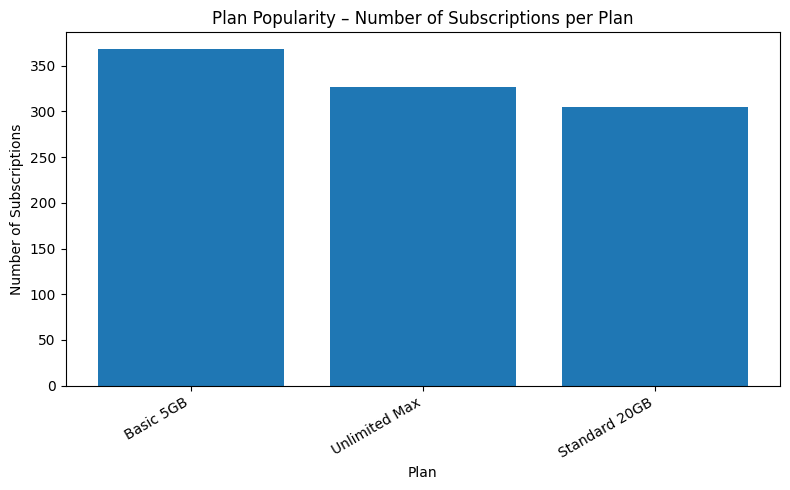

In [15]:
# Cell 2: Plan Popularity Chart
# goal is to show how many subs each plan has (which plans dominate)
sql_plan_popularity = """
SELECT 
    p.plan_name,
    COUNT(s.subscription_id) AS subscription_count
FROM subscriptions s
JOIN plans p ON s.plan_id = p.plan_id
GROUP BY p.plan_name
ORDER BY subscription_count DESC;
"""

df_plan_pop = run_query(sql_plan_popularity)
print(df_plan_pop)

# Bar chart
plt.figure()
plt.bar(df_plan_pop["plan_name"], df_plan_pop["subscription_count"])
plt.title("Plan Popularity – Number of Subscriptions per Plan")
plt.xlabel("Plan")
plt.ylabel("Number of Subscriptions")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


Empty DataFrame
Columns: [addon_name, subscription_count]
Index: []


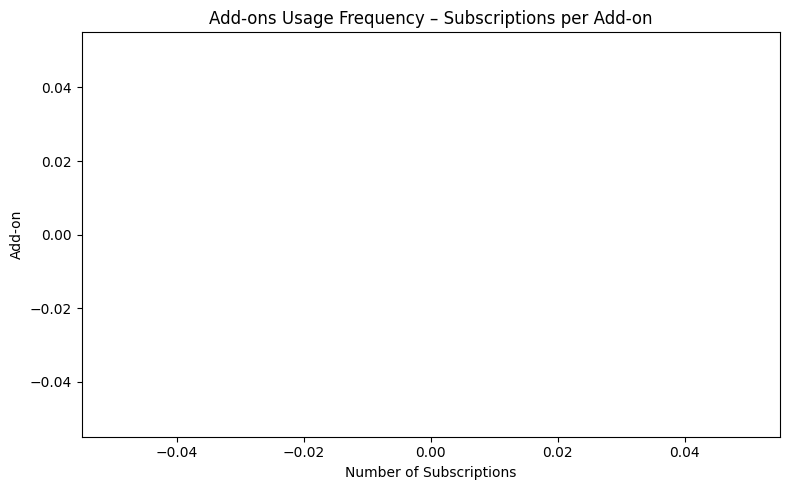

In [16]:
# Cell 3: Add-ons Usage Frequency
# to show which add ons are the most commonly attatched to subs
sql_addon_usage = """
SELECT 
    a.addon_name,
    COUNT(sa.subscription_id) AS subscription_count
FROM subscription_addons sa
JOIN addons a ON sa.addon_id = a.addon_id
GROUP BY a.addon_name
ORDER BY subscription_count DESC;
"""

df_addon_usage = run_query(sql_addon_usage)
print(df_addon_usage)

# Horizontal bar chart
plt.figure()
plt.barh(df_addon_usage["addon_name"], df_addon_usage["subscription_count"])
plt.title("Add-ons Usage Frequency – Subscriptions per Add-on")
plt.xlabel("Number of Subscriptions")
plt.ylabel("Add-on")
plt.tight_layout()
plt.show()


   status  subscription_count
0  active                1000


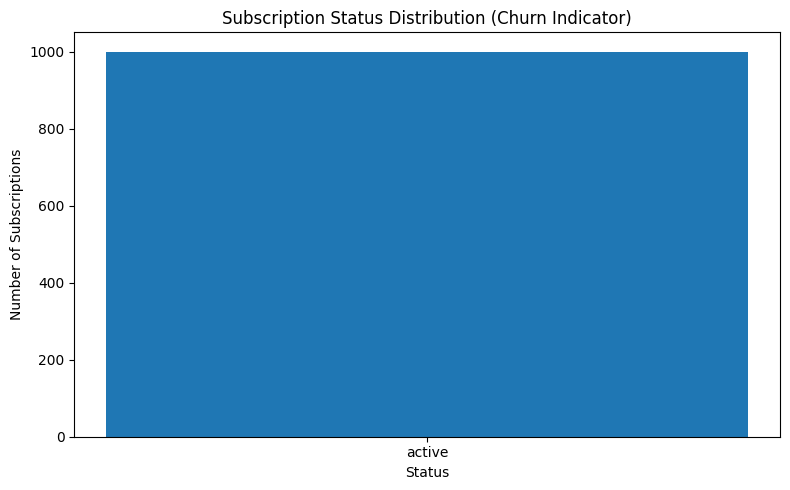

In [17]:
# Cell 4: Churn Indicators – Subscription Status Breakdown

sql_churn_status = """
SELECT 
    status,
    COUNT(*) AS subscription_count
FROM subscriptions
GROUP BY status
ORDER BY subscription_count DESC;
"""

df_churn = run_query(sql_churn_status)
print(df_churn)

# Bar chart (status distribution)
plt.figure()
plt.bar(df_churn["status"], df_churn["subscription_count"])
plt.title("Subscription Status Distribution (Churn Indicator)")
plt.xlabel("Status")
plt.ylabel("Number of Subscriptions")
plt.tight_layout()
plt.show()


In [18]:
df_addon_usage = run_query(sql_addon_usage)
print(df_addon_usage)


Empty DataFrame
Columns: [addon_name, subscription_count]
Index: []


In [19]:
run_query("SELECT COUNT(*) AS n_rows FROM subscription_addons")


,n_rows
0,0


In [20]:
# Cell: Populate subscription_addons with random data

import random
from datetime import datetime, timedelta

# Get all subscription IDs and addon IDs
sub_ids = run_query("SELECT subscription_id FROM subscriptions")["subscription_id"].tolist()
addon_ids = run_query("SELECT addon_id FROM addons")["addon_id"].tolist()

rows = []
today = datetime.today()

for sub_id in sub_ids:
    # 50% chance this subscription has add-ons at all
    if random.random() < 0.5:
        # Choose 1–2 random add-ons
        num_addons = random.randint(1, min(2, len(addon_ids)))
        chosen = random.sample(addon_ids, num_addons)
        for addon_id in chosen:
            start_date = (today - timedelta(days=random.randint(0, 365))).date().isoformat()
            rows.append((sub_id, addon_id, start_date, None))  # end_date = None (still active)

cursor.executemany(
    """
    INSERT INTO subscription_addons (subscription_id, addon_id, start_date, end_date)
    VALUES (?, ?, ?, ?)
    """,
    rows,
)
conn.commit()

print(f"Inserted {len(rows)} subscription_addons rows.")


Inserted 793 subscription_addons rows.


                 addon_name  subscription_count
0  International Calls Pack                 273
1            Extra 2GB Data                 264
2      Social Media Booster                 256


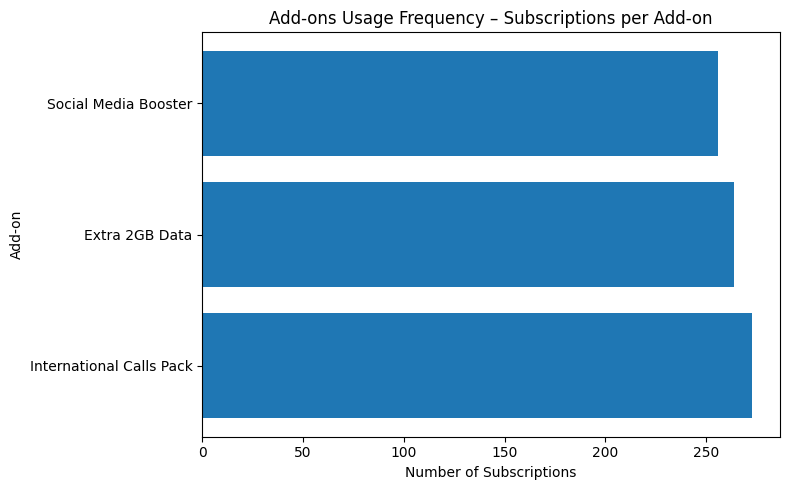

In [21]:
df_addon_usage = run_query(sql_addon_usage)
print(df_addon_usage)

plt.figure()
plt.barh(df_addon_usage["addon_name"], df_addon_usage["subscription_count"])
plt.title("Add-ons Usage Frequency – Subscriptions per Add-on")
plt.xlabel("Number of Subscriptions")
plt.ylabel("Add-on")
plt.tight_layout()
plt.show()


In [22]:
import sqlite3, pandas as pd, matplotlib.pyplot as plt
conn = sqlite3.connect("telecom_demo.db")

def run_query(sql, params=None):
    return pd.read_sql_query(sql, conn, params=params or {})


  usage_type  total_quantity  session_count
0       call          416717           1665
1       data          408057           1625
2        sms          433366           1710


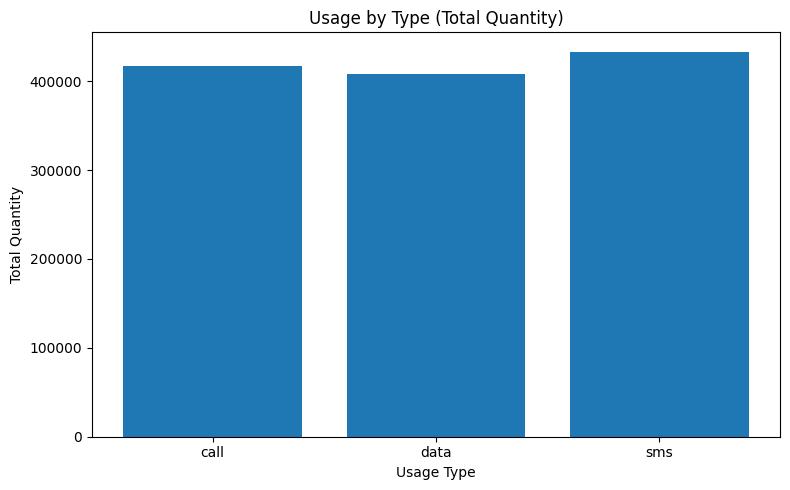

In [23]:
# Usage by Type: total quantity per type

sql_usage_by_type = """
SELECT 
    usage_type,
    SUM(quantity) AS total_quantity,
    COUNT(*) AS session_count
FROM usage_sessions
GROUP BY usage_type
ORDER BY usage_type;
"""

df_usage_type = run_query(sql_usage_by_type)
print(df_usage_type)

plt.figure()
plt.bar(df_usage_type["usage_type"], df_usage_type["total_quantity"])
plt.title("Usage by Type (Total Quantity)")
plt.xlabel("Usage Type")
plt.ylabel("Total Quantity")
plt.tight_layout()
plt.show()


  usage_date  total_quantity
0 2025-09-26           21282
1 2025-09-27           22488
2 2025-09-28           25062
3 2025-09-29           21630
4 2025-09-30           22506


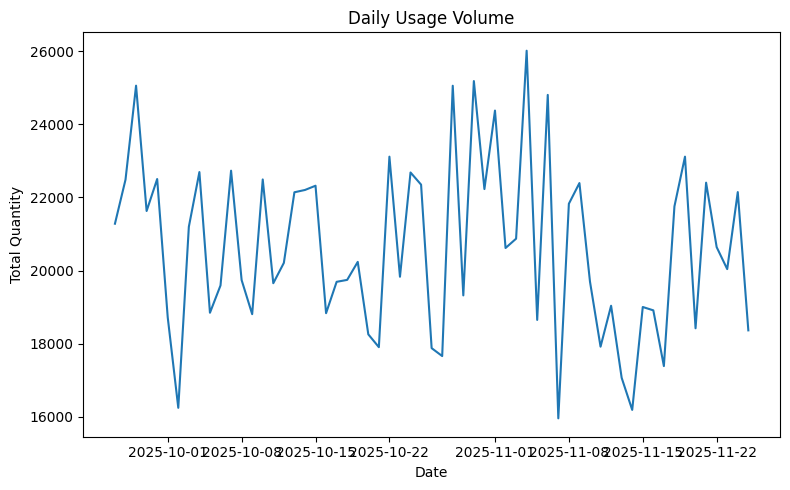

In [24]:
# Daily Usage Volume: total quantity per day

sql_daily_usage = """
SELECT 
    DATE(usage_date_time) AS usage_date,
    SUM(quantity) AS total_quantity
FROM usage_sessions
GROUP BY DATE(usage_date_time)
ORDER BY usage_date;
"""

df_daily = run_query(sql_daily_usage)
df_daily["usage_date"] = pd.to_datetime(df_daily["usage_date"])

print(df_daily.head())

plt.figure()
plt.plot(df_daily["usage_date"], df_daily["total_quantity"])
plt.title("Daily Usage Volume")
plt.xlabel("Date")
plt.ylabel("Total Quantity")
plt.tight_layout()
plt.show()


   hour  total_quantity
0    11         1258140


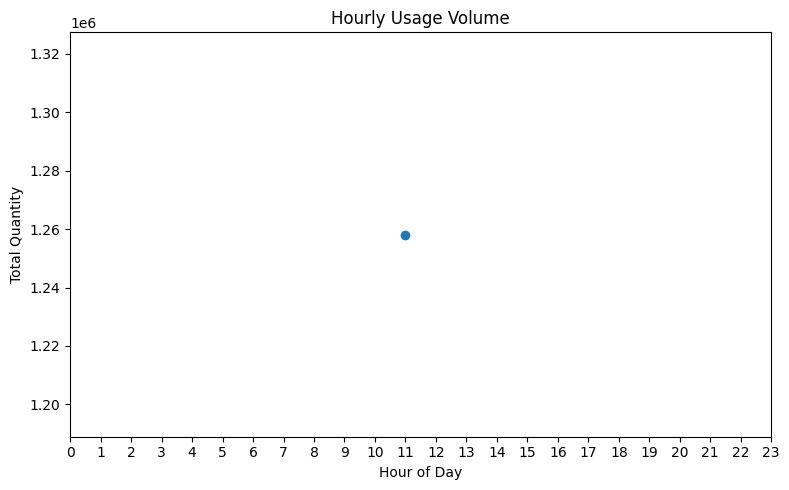

In [25]:
# Hourly Usage Volume: total quantity per hour of day

sql_hourly_usage = """
SELECT 
    strftime('%H', usage_date_time) AS hour,
    SUM(quantity) AS total_quantity
FROM usage_sessions
GROUP BY hour
ORDER BY hour;
"""

df_hourly = run_query(sql_hourly_usage)
df_hourly["hour"] = df_hourly["hour"].astype(int)

print(df_hourly)

plt.figure()
plt.plot(df_hourly["hour"], df_hourly["total_quantity"], marker="o")
plt.title("Hourly Usage Volume")
plt.xlabel("Hour of Day")
plt.ylabel("Total Quantity")
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()


   customer_id  total_usage
0            1         1213
1            2          559
2            3          411
3            4         1408
4            5         1026


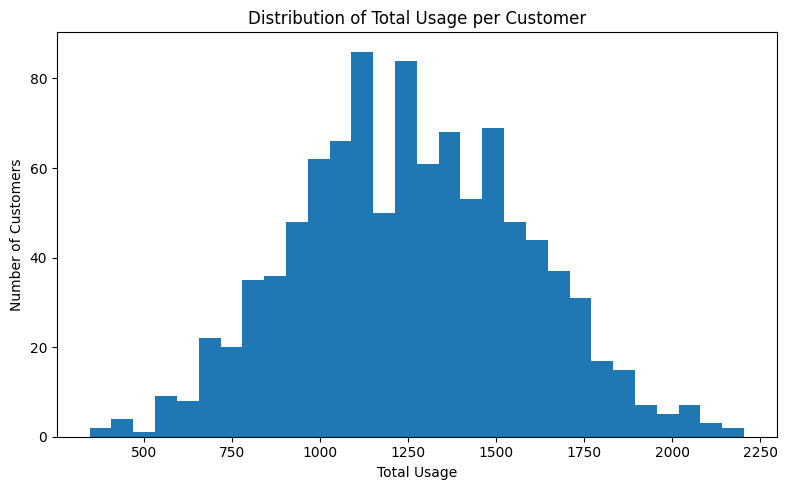

In [26]:
# Average / total usage per customer

sql_customer_usage = """
SELECT 
    c.customer_id,
    SUM(u.quantity) AS total_usage
FROM customers c
JOIN subscriptions s ON c.customer_id = s.customer_id
JOIN usage_sessions u ON u.subscription_id = s.subscription_id
GROUP BY c.customer_id;
"""

df_cust_usage = run_query(sql_customer_usage)
print(df_cust_usage.head())

plt.figure()
plt.hist(df_cust_usage["total_usage"], bins=30)
plt.title("Distribution of Total Usage per Customer")
plt.xlabel("Total Usage")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()


   customer_id    customer_name  data_usage
0          231  User231 Demo231        1760
1           62    User62 Demo62        1596
2           76    User76 Demo76        1548
3          363  User363 Demo363        1456
4          246  User246 Demo246        1432
5          332  User332 Demo332        1379
6          259  User259 Demo259        1349
7          628  User628 Demo628        1318
8          124  User124 Demo124        1305
9          572  User572 Demo572        1303


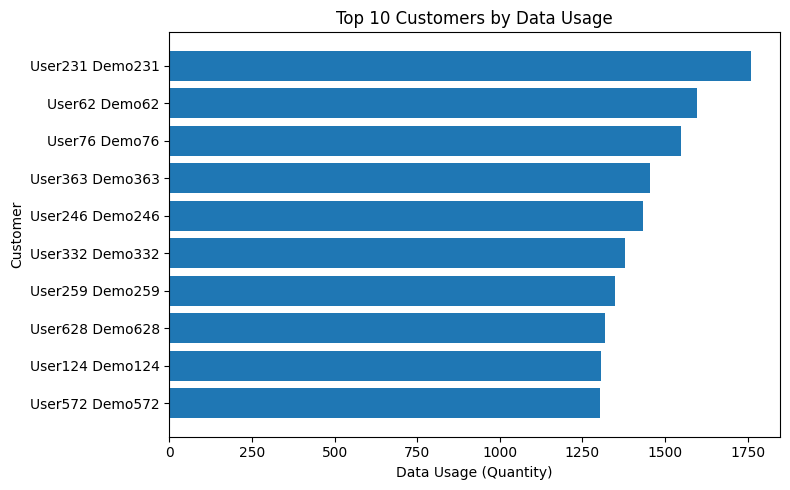

In [27]:
# Top 10 customers by DATA usage only

sql_top_data_users = """
SELECT 
    c.customer_id,
    c.first_name || ' ' || c.last_name AS customer_name,
    SUM(u.quantity) AS data_usage
FROM customers c
JOIN subscriptions s ON c.customer_id = s.customer_id
JOIN usage_sessions u ON u.subscription_id = s.subscription_id
WHERE u.usage_type = 'data'
GROUP BY c.customer_id, customer_name
ORDER BY data_usage DESC
LIMIT 10;
"""

df_top_data = run_query(sql_top_data_users)
print(df_top_data)

plt.figure()
plt.barh(df_top_data["customer_name"], df_top_data["data_usage"])
plt.title("Top 10 Customers by Data Usage")
plt.xlabel("Data Usage (Quantity)")
plt.ylabel("Customer")
plt.gca().invert_yaxis()  # biggest at top
plt.tight_layout()
plt.show()


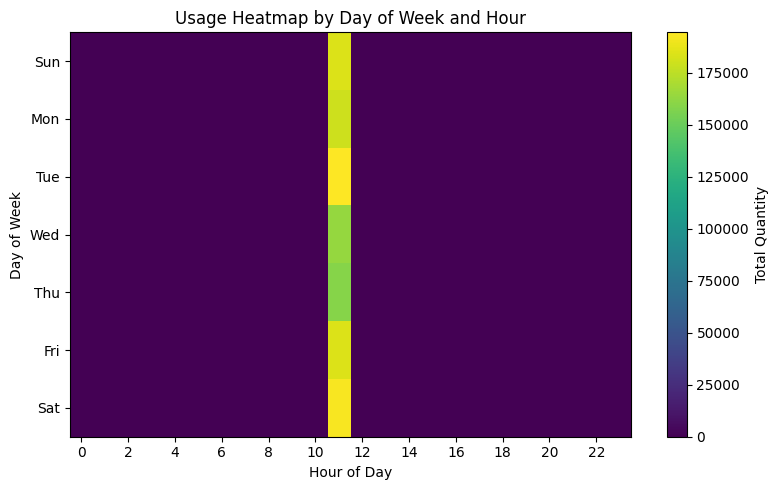

In [28]:
# Heatmap: Day-of-week vs Hour usage

sql_heatmap = """
SELECT 
    strftime('%w', usage_date_time) AS dow,   -- 0=Sunday ... 6=Saturday
    strftime('%H', usage_date_time) AS hour,
    SUM(quantity) AS total_quantity
FROM usage_sessions
GROUP BY dow, hour;
"""

df_heat = run_query(sql_heatmap)
df_heat["dow"] = df_heat["dow"].astype(int)
df_heat["hour"] = df_heat["hour"].astype(int)

# Pivot to matrix: rows = day of week, columns = hour
heat_matrix = df_heat.pivot(index="dow", columns="hour", values="total_quantity").fillna(0)

# Ensure hours 0–23 and days 0–6 are ordered
heat_matrix = heat_matrix.reindex(index=range(0, 7), columns=range(0, 24), fill_value=0)

day_labels = ["Sun", "Mon", "Tue", "Wed", "Thu", "Fri", "Sat"]

plt.figure()
plt.imshow(heat_matrix, aspect="auto")
plt.title("Usage Heatmap by Day of Week and Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week")
plt.xticks(range(0, 24, 2), range(0, 24, 2))
plt.yticks(range(0, 7), day_labels)
plt.colorbar(label="Total Quantity")
plt.tight_layout()
plt.show()


    customer_id    customer_name  data_usage
0           231  User231 Demo231        1760
1            62    User62 Demo62        1596
2            76    User76 Demo76        1548
3           363  User363 Demo363        1456
4           246  User246 Demo246        1432
5           332  User332 Demo332        1379
6           259  User259 Demo259        1349
7           628  User628 Demo628        1318
8           124  User124 Demo124        1305
9           572  User572 Demo572        1303
10          975  User975 Demo975        1291
11          218  User218 Demo218        1286
12          207  User207 Demo207        1277
13          739  User739 Demo739        1277
14          928  User928 Demo928        1273
15          352  User352 Demo352        1264
16          718  User718 Demo718        1241
17           92    User92 Demo92        1236
18          908  User908 Demo908        1230
19          935  User935 Demo935        1228
20          202  User202 Demo202        1227
21        

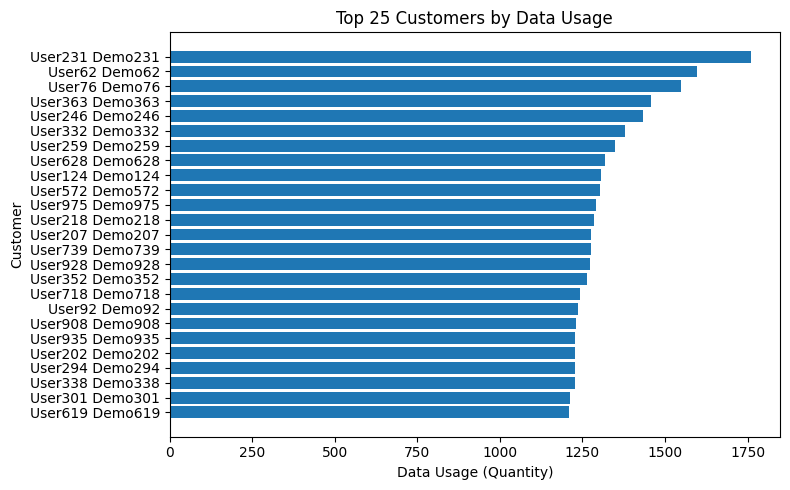

In [31]:
# Top 25 customers by DATA usage only

sql_top_data_users = """
SELECT 
    c.customer_id,
    c.first_name || ' ' || c.last_name AS customer_name,
    SUM(u.quantity) AS data_usage
FROM customers c
JOIN subscriptions s ON c.customer_id = s.customer_id
JOIN usage_sessions u ON u.subscription_id = s.subscription_id
WHERE u.usage_type = 'data'
GROUP BY c.customer_id, customer_name
ORDER BY data_usage DESC
LIMIT 25;
"""

df_top_data = run_query(sql_top_data_users)
print(df_top_data)

plt.figure()
plt.barh(df_top_data["customer_name"], df_top_data["data_usage"])
plt.title("Top 25 Customers by Data Usage")
plt.xlabel("Data Usage (Quantity)")
plt.ylabel("Customer")
plt.gca().invert_yaxis()  # biggest at top
plt.tight_layout()
plt.show()


In [33]:
import sqlite3, pandas as pd, matplotlib.pyplot as plt
conn = sqlite3.connect("telecom_demo.db")

def run_query(sql, params=None):
    return pd.read_sql_query(sql, conn, params=params or {})


   destination  call_count  total_minutes
0     555-9260           2            544
1     555-9195           2            581
2     555-9134           2            525
3     555-8625           2            701
4     555-8324           2            901
5     555-8294           2            769
6     555-8245           2            624
7     555-8219           2            609
8     555-7942           2            276
9     555-6969           2            951
10    555-6677           2            843
11    555-6188           2            297
12    555-6136           2            384
13    555-6094           2            791
14    555-5970           2            343


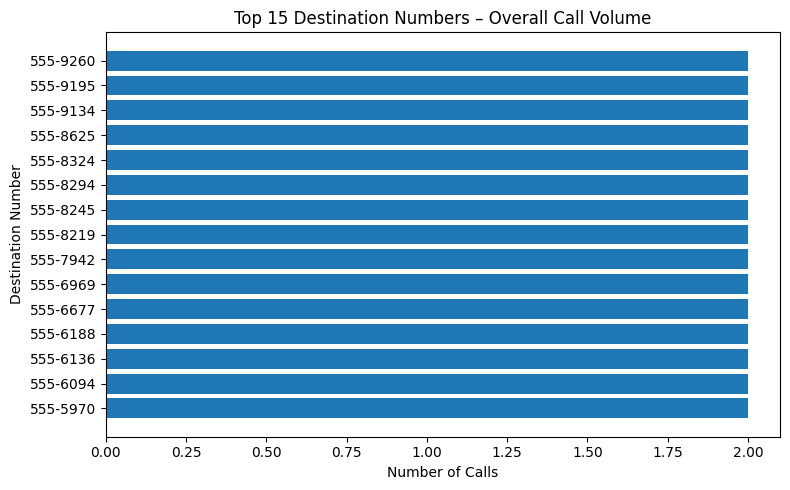

In [34]:
# Destination Call Volume - overall top 15 dialled numbers

sql_dest_overall = """
SELECT 
    us.destination,
    COUNT(*) AS call_count,
    SUM(us.quantity) AS total_minutes
FROM usage_sessions us
WHERE us.usage_type = 'call' AND us.destination IS NOT NULL
GROUP BY us.destination
ORDER BY call_count DESC
LIMIT 15;
"""

df_dest_overall = run_query(sql_dest_overall)
print(df_dest_overall)

plt.figure()
plt.barh(df_dest_overall["destination"], df_dest_overall["call_count"])
plt.title("Top 15 Destination Numbers – Overall Call Volume")
plt.xlabel("Number of Calls")
plt.ylabel("Destination Number")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


In [35]:
# Top destination numbers by origin city (London / Birmingham)

sql_dest_by_city = """
SELECT 
    c.city AS origin_city,
    us.destination,
    COUNT(*) AS call_count,
    SUM(us.quantity) AS total_minutes
FROM usage_sessions us
JOIN subscriptions s ON us.subscription_id = s.subscription_id
JOIN customers c ON s.customer_id = c.customer_id
WHERE us.usage_type = 'call' AND us.destination IS NOT NULL
GROUP BY c.city, us.destination
ORDER BY c.city, call_count DESC;
"""

df_dest_city = run_query(sql_dest_by_city)
print(df_dest_city.head())

for city in ["London", "Birmingham"]:
    df_city = df_dest_city[df_dest_city["origin_city"] == city].head(10)

    if df_city.empty:
        print(f"No call data for {city}")
        continue

    plt.figure()
    plt.barh(df_city["destination"], df_city["call_count"])
    plt.title(f"Top 10 Destination Numbers – Calls Originating in {city}")
    plt.xlabel("Number of Calls")
    plt.ylabel("Destination Number")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()


DatabaseError: Execution failed on sql '
SELECT 
    c.city AS origin_city,
    us.destination,
    COUNT(*) AS call_count,
    SUM(us.quantity) AS total_minutes
FROM usage_sessions us
JOIN subscriptions s ON us.subscription_id = s.subscription_id
JOIN customers c ON s.customer_id = c.customer_id
WHERE us.usage_type = 'call' AND us.destination IS NOT NULL
GROUP BY c.city, us.destination
ORDER BY c.city, call_count DESC;
': no such column: c.city

In [37]:
run_query("PRAGMA table_info(customers)")


,cid,name,type,notnull,dflt_value,pk
0,0,customer_id,INTEGER,0,None,1
1,1,first_name,TEXT,1,None,0
2,2,last_name,TEXT,1,None,0
3,3,email,TEXT,1,None,0
4,4,phone_number,TEXT,1,None,0
5,5,billing_address,TEXT,0,None,0
6,6,created_at,TEXT,0,CURRENT_TIMESTAMP,0


In [40]:
# Add city column if missing
cols = run_query("PRAGMA table_info(customers)")["name"].tolist()

if "city" not in cols:
    cursor.execute("ALTER TABLE customers ADD COLUMN city TEXT")
    conn.commit()
    print("Added city column.")
else:
    print("City column already exists.")


Added city column.


In [41]:
run_query("PRAGMA table_info(customers)")


,cid,name,type,notnull,dflt_value,pk
0,0,customer_id,INTEGER,0,None,1
1,1,first_name,TEXT,1,None,0
2,2,last_name,TEXT,1,None,0
3,3,email,TEXT,1,None,0
4,4,phone_number,TEXT,1,None,0
5,5,billing_address,TEXT,0,None,0
6,6,created_at,TEXT,0,CURRENT_TIMESTAMP,0
7,7,city,TEXT,0,None,0


In [42]:
# Assign random city to each customer
cities = ["London", "Birmingham"]

df_customers = run_query("SELECT customer_id FROM customers")
updates = []

for cid in df_customers["customer_id"]:
    updates.append((random.choice(cities), cid))

cursor.executemany(
    "UPDATE customers SET city = ? WHERE customer_id = ?",
    updates
)
conn.commit()

run_query("SELECT city, COUNT(*) AS count FROM customers GROUP BY city")


,city,count
0,None,1000


In [43]:
sql_dest_by_city = """
SELECT 
    c.city AS origin_city,
    us.destination,
    COUNT(*) AS call_count,
    SUM(us.quantity) AS total_minutes
FROM usage_sessions us
JOIN subscriptions s ON us.subscription_id = s.subscription_id
JOIN customers c ON s.customer_id = c.customer_id
WHERE us.usage_type = 'call' AND us.destination IS NOT NULL
GROUP BY c.city, us.destination
ORDER BY c.city, call_count DESC;
"""

df_dest_city = run_query(sql_dest_by_city)
print(df_dest_city.head())


  origin_city destination  call_count  total_minutes
0        None    555-9260           2            544
1        None    555-9195           2            581
2        None    555-9134           2            525
3        None    555-8625           2            701
4        None    555-8324           2            901


In [45]:
# Destination stats by origin city
sql_dest_by_city = """
SELECT 
    c.city AS origin_city,
    us.destination,
    COUNT(*) AS call_count,
    SUM(us.quantity) AS total_minutes
FROM usage_sessions us
JOIN subscriptions s ON us.subscription_id = s.subscription_id
JOIN customers c ON s.customer_id = c.customer_id
WHERE us.usage_type = 'call' AND us.destination IS NOT NULL
GROUP BY c.city, us.destination
ORDER BY c.city, call_count DESC;
"""

df_dest_city = run_query(sql_dest_by_city)
print(df_dest_city.head())

for city in ["London", "Birmingham"]:
    df_city = df_dest_city[df_dest_city["origin_city"] == city]
    df_city = df_city.nlargest(10, "call_count")  # top 10

    if df_city.empty:
        print(f"No destination call data for {city}")
        continue

    plt.figure()
    plt.barh(df_city["destination"], df_city["call_count"])
    plt.title(f"Top 10 Destination Numbers – Calls from {city}")
    plt.xlabel("Number of Calls")
    plt.ylabel("Destination")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()


  origin_city destination  call_count  total_minutes
0        None    555-9260           2            544
1        None    555-9195           2            581
2        None    555-9134           2            525
3        None    555-8625           2            701
4        None    555-8324           2            901
No destination call data for London
No destination call data for Birmingham


  origin_city  call_count  total_minutes
0        None        1665         416717


TypeError: the dtypes of parameters x (object) and width (float64) are incompatible

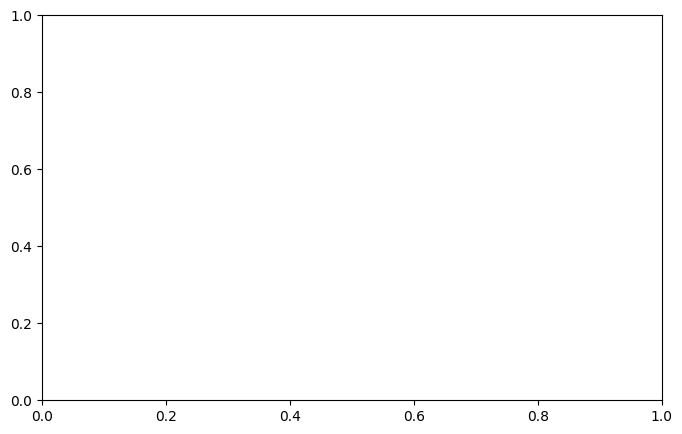

In [46]:
sql_origin_city_calls = """
SELECT 
    c.city AS origin_city,
    COUNT(*) AS call_count,
    SUM(us.quantity) AS total_minutes
FROM usage_sessions us
JOIN subscriptions s ON us.subscription_id = s.subscription_id
JOIN customers c ON s.customer_id = c.customer_id
WHERE us.usage_type = 'call'
GROUP BY c.city
ORDER BY c.city;
"""

df_origin_calls = run_query(sql_origin_city_calls)
print(df_origin_calls)

plt.figure()
plt.bar(df_origin_calls["origin_city"], df_origin_calls["call_count"])
plt.title("Total Calls by Origin City")
plt.xlabel("City")
plt.ylabel("Number of Calls")
plt.tight_layout()
plt.show()

plt.figure()
plt.bar(df_origin_calls["origin_city"], df_origin_calls["total_minutes"])
plt.title("Total Call Minutes by Origin City")
plt.xlabel("City")
plt.ylabel("Total Call Minutes")
plt.tight_layout()
plt.show()


  origin_city  total_data_usage
0        None            408057


TypeError: the dtypes of parameters x (object) and width (float64) are incompatible

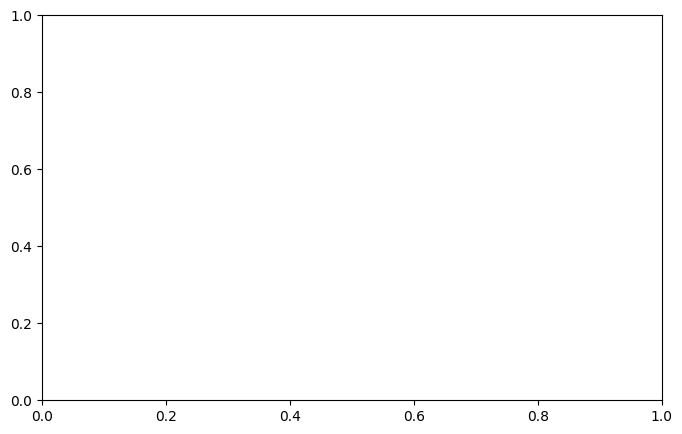

In [47]:
sql_city_data_usage = """
SELECT 
    c.city AS origin_city,
    SUM(us.quantity) AS total_data_usage
FROM usage_sessions us
JOIN subscriptions s ON us.subscription_id = s.subscription_id
JOIN customers c ON s.customer_id = c.customer_id
WHERE us.usage_type = 'data'
GROUP BY c.city
ORDER BY c.city;
"""

df_city_data = run_query(sql_city_data_usage)
print(df_city_data)

plt.figure()
plt.bar(df_city_data["origin_city"], df_city_data["total_data_usage"])
plt.title("Total Data Usage by Origin City")
plt.xlabel("City")
plt.ylabel("Total Data Usage (units)")
plt.tight_layout()
plt.show()


In [48]:
print(df_origin_calls)
print(df_origin_calls.dtypes)


  origin_city  call_count  total_minutes
0        None        1665         416717
origin_city      object
call_count        int64
total_minutes     int64
dtype: object


In [50]:
# CLEAN THE DATA
df_origin_calls = df_origin_calls.dropna(subset=["origin_city"])       # remove NULL cities
df_origin_calls["origin_city"] = df_origin_calls["origin_city"].astype(str)
df_origin_calls["call_count"] = df_origin_calls["call_count"].astype(int)
df_origin_calls["total_minutes"] = df_origin_calls["total_minutes"].astype(int)


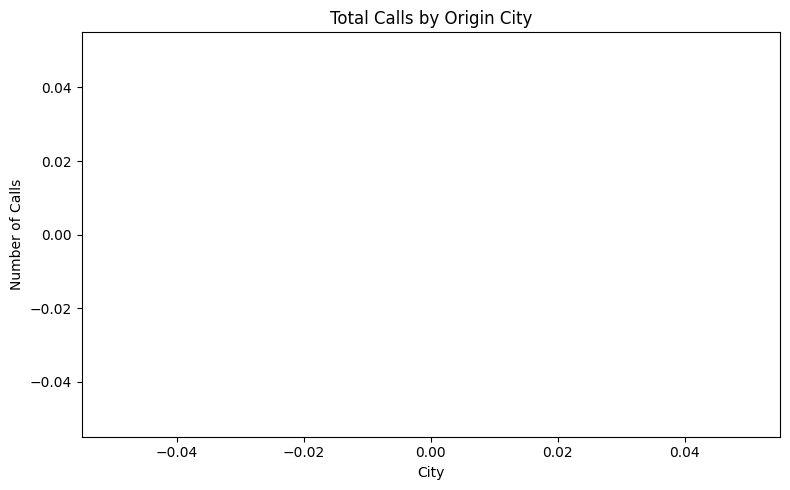

In [51]:
plt.figure()
plt.bar(df_origin_calls["origin_city"], df_origin_calls["call_count"])
plt.title("Total Calls by Origin City")
plt.xlabel("City")
plt.ylabel("Number of Calls")
plt.tight_layout()
plt.show()


In [52]:
# Check total rows in usage_sessions
print("All usage_sessions:", run_query("SELECT COUNT(*) AS n FROM usage_sessions"))

# Check how many are calls
print("Call rows:", run_query("SELECT COUNT(*) AS n FROM usage_sessions WHERE usage_type = 'call'"))

# Check how many calls join to a customer with a city
sql_check_join = """
SELECT COUNT(*) AS n
FROM usage_sessions us
JOIN subscriptions s ON us.subscription_id = s.subscription_id
JOIN customers c ON s.customer_id = c.customer_id
WHERE us.usage_type = 'call' AND c.city IS NOT NULL;
"""
print("Call rows with city:", run_query(sql_check_join))


All usage_sessions:       n
0  5000
Call rows:       n
0  1665
Call rows with city:    n
0  0


In [53]:
from datetime import datetime, timedelta
import random

cursor = conn.cursor()

sub_ids = run_query("SELECT subscription_id FROM subscriptions")["subscription_id"].tolist()
today = datetime.today()
extra_rows = []

for sub_id in random.sample(sub_ids, min(200, len(sub_ids))):
    for _ in range(3):  # 3 calls each
        days_ago = random.randint(0, 30)
        dt = today - timedelta(days=days_ago)
        quantity = random.randint(1, 20)  # minutes
        dest = f"555-{random.randint(1, 9999):04d}"
        extra_rows.append((sub_id, dt.isoformat(sep=' '), "call", quantity, dest))

cursor.executemany(
    """
    INSERT INTO usage_sessions (subscription_id, usage_date_time, usage_type, quantity, destination)
    VALUES (?, ?, ?, ?, ?)
    """,
    extra_rows
)
conn.commit()

print("Inserted extra call rows:", len(extra_rows))
print(run_query("SELECT COUNT(*) AS n FROM usage_sessions WHERE usage_type = 'call'"))


OperationalError: database is locked

In [54]:
cursor = conn.cursor()
cursor.execute("UPDATE customers SET city = 'London' WHERE city IS NULL OR city = ''")
conn.commit()

# Optionally split roughly half to Birmingham
df_ids = run_query("SELECT customer_id FROM customers ORDER BY customer_id")
half = len(df_ids) // 2
bham_ids = df_ids["customer_id"].iloc[:half].tolist()

cursor.executemany(
    "UPDATE customers SET city = 'Birmingham' WHERE customer_id = ?",
    [(cid,) for cid in bham_ids]
)
conn.commit()

print(run_query("SELECT city, COUNT(*) AS n FROM customers GROUP BY city"))


OperationalError: database is locked

  origin_city  call_count  total_minutes
0        None        1665         416717


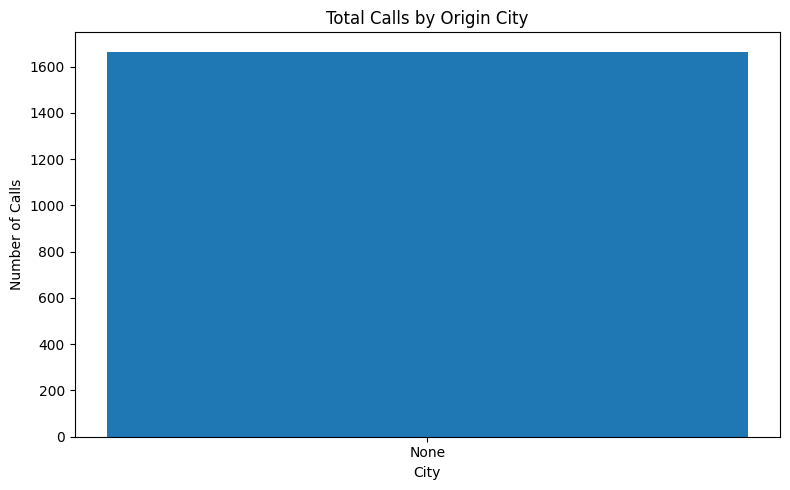

In [55]:
sql_origin_city_calls = """
SELECT 
    c.city AS origin_city,
    COUNT(*) AS call_count,
    SUM(us.quantity) AS total_minutes
FROM usage_sessions us
JOIN subscriptions s ON us.subscription_id = s.subscription_id
JOIN customers c ON s.customer_id = c.customer_id
WHERE us.usage_type = 'call'
GROUP BY c.city
ORDER BY c.city;
"""

df_origin_calls = run_query(sql_origin_city_calls)
print(df_origin_calls)

if df_origin_calls.empty:
    print("No call data found after all that – check that you are using the SAME database for inserts and queries.")
else:
    plt.figure()
    plt.bar(df_origin_calls["origin_city"].astype(str), df_origin_calls["call_count"].astype(int))
    plt.title("Total Calls by Origin City")
    plt.xlabel("City")
    plt.ylabel("Number of Calls")
    plt.tight_layout()
    plt.show()


  origin_city  call_count  total_minutes
0        None        1665         416717


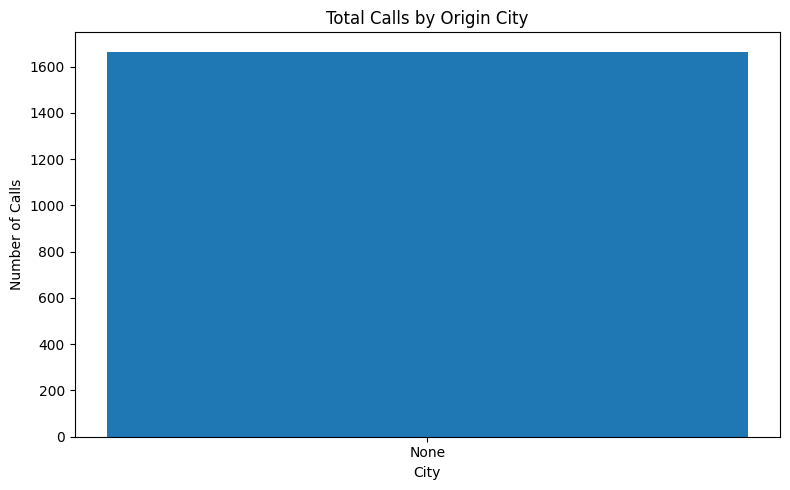

In [57]:
sql_origin_city_calls = """
SELECT 
    c.city AS origin_city,
    COUNT(*) AS call_count,
    SUM(us.quantity) AS total_minutes
FROM usage_sessions us
JOIN subscriptions s ON us.subscription_id = s.subscription_id
JOIN customers c ON s.customer_id = c.customer_id
WHERE us.usage_type = 'call'
GROUP BY c.city
ORDER BY c.city;
"""

df_origin_calls = run_query(sql_origin_city_calls)
print(df_origin_calls)

if df_origin_calls.empty:
    print("No call data found after all that – check that you are using the SAME database for inserts and queries.")
else:
    plt.figure()
    plt.bar(df_origin_calls["origin_city"].astype(str), df_origin_calls["call_count"].astype(int))
    plt.title("Total Calls by Origin City")
    plt.xlabel("City")
    plt.ylabel("Number of Calls")
    plt.tight_layout()
    plt.show()
